<a href="https://colab.research.google.com/github/JustinStutler/sarkar-computer-vision-lectures/blob/main/4_2_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SIFT Matching Assignment
Justin Stutler

# Assignment Instructions

For a chosen object, take photographs from 16 different angles. Use the OpenCV SIFT feature detector and matching to analyze the images. Observe the effectiveness of the feature detector in matching the images based on the changes in the viewpoint. Study the variation in matching with respect to viewpoint changes. Evaluate the quality of the matches and provide a quantitative measure of the detector's performance.

# My Object
I chose a hat with stripes and a patch on the front. I placed it in the middle of a circular table in my living room and took 16 photos, moving around the circle as I did so.

# Init

In [27]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    data_dir = '/content/drive/MyDrive/4.2 Photos/'
except ImportError:
    data_dir = './'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as scimage
import cv2
print(cv2.__version__)

np.set_printoptions(precision=2, suppress=True)

5.0.0


In [29]:
# Helper functions copied from the module notebook

# 1D Gaussian kernel
def gaussian (x, sigma):
    g = np.exp(-(x**2/(2*sigma*sigma)))*(1/(np.sqrt(2*np.pi)*sigma))
    return (g/g.sum())

# Gaussian convolution code
def image_convolve_gaussian (image, sigma) :
    N = np.round(3*(sigma+1))
    t = np.arange(-N, N)
    g = gaussian(t, sigma) # 1D gaussian kernel
    output = image.copy()
    for i in range (image.shape[0]):   # process rows
        output[i,:] = scimage.convolve(output[i, :], g)
    for j in range (image.shape[1]):   # process columns
        output[:, j] = scimage.convolve(output[:, j], g)
    return (output)

def unpackSIFTOctave(keypoint):
    """unpackSIFTOctave(kpt)->(octave,layer,scale)
    @created by Silencer at 2018.01.23 11:12:30 CST
    @brief Unpack Sift Keypoint by Silencer
    @param kpt: cv2.KeyPoint (of SIFT)
    """
    _octave = keypoint.octave
    octave = _octave&0xFF
    layer  = (_octave>>8)&0xFF
    if octave>=128:
        octave |= -128
    if octave>=0:
        scale = float(1/(1<<octave))
    else:
        scale = float(1<<-octave)
    return (octave, layer, scale)

## Load the Images

The images are high resolution. SIFT is inefficient with too high of a resolution, so the images are smoothed with a gaussian and then shrunk to 1/4 the original size.

Loaded 16 images, size of each view: (1008, 567)


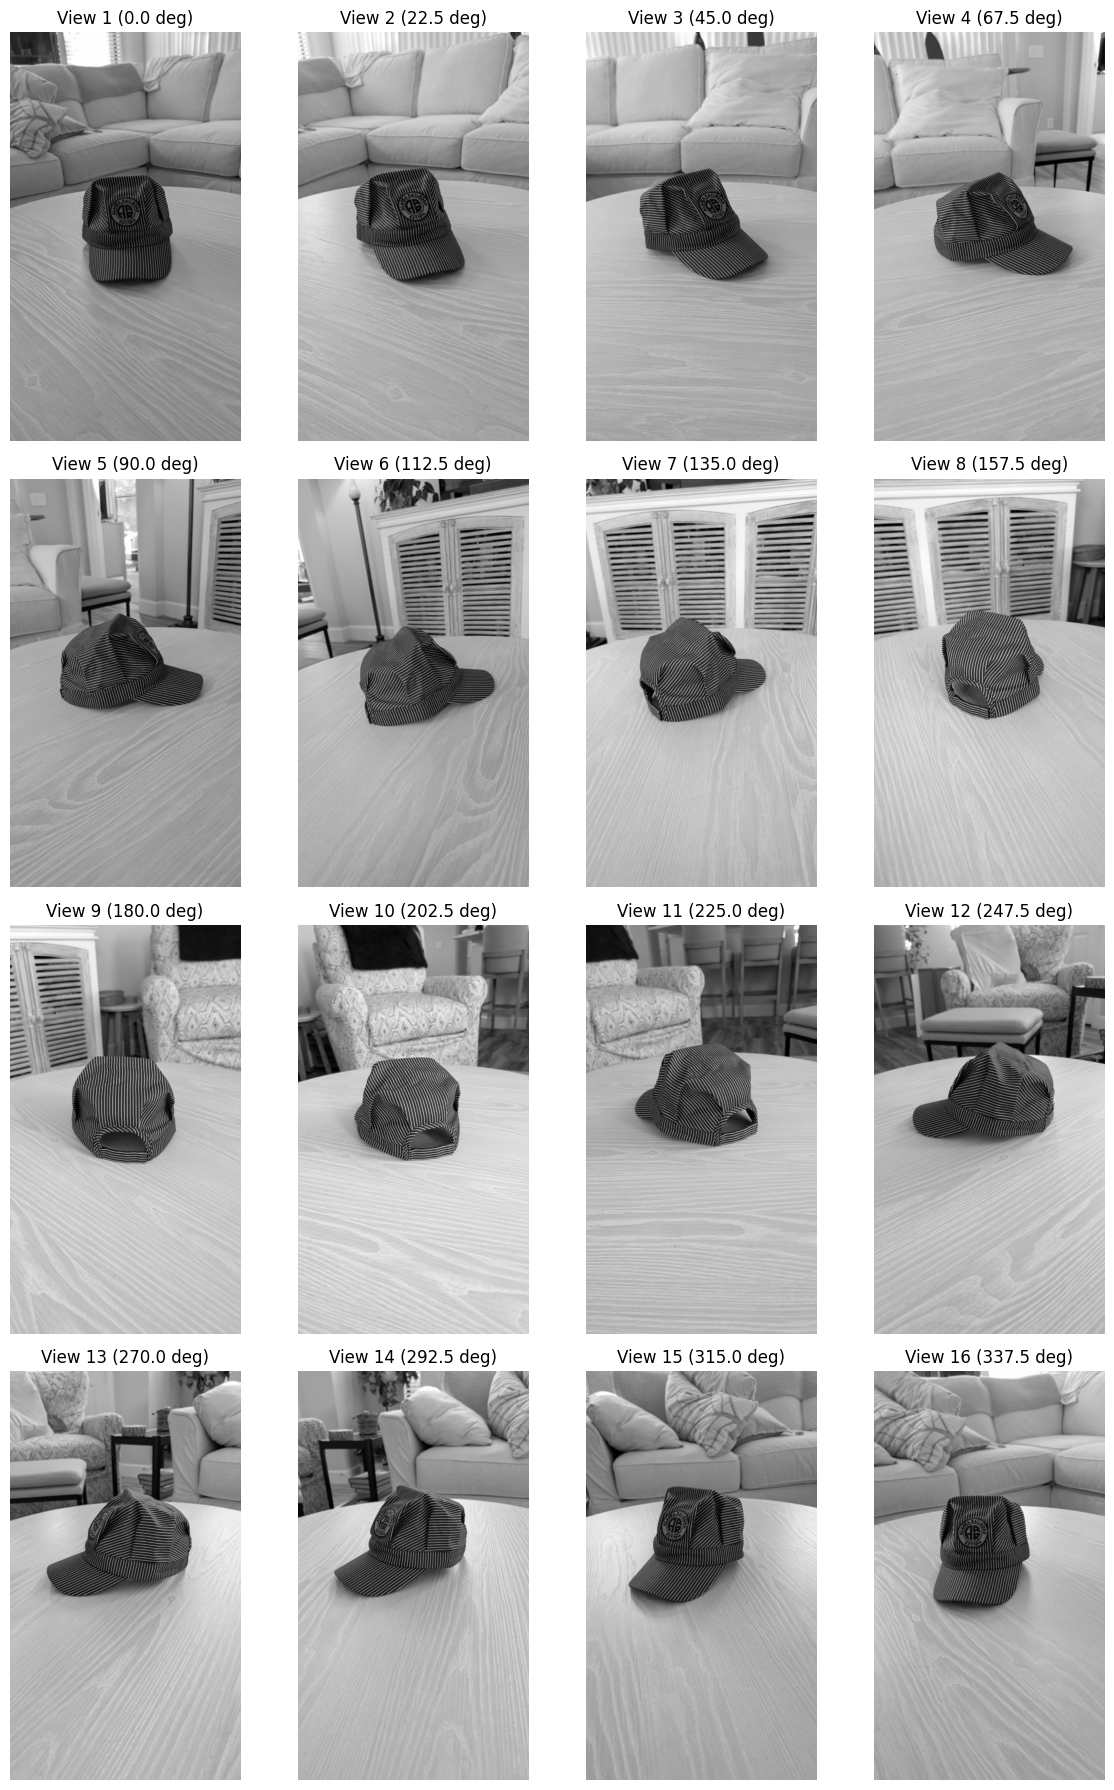

In [30]:
N_VIEWS = 16
STEP_DEG = 360 / N_VIEWS   # camera moves ~22.5 degrees between shots

hat_images = []
for i in range(N_VIEWS):
    image = cv2.imread(data_dir + '{}.jpg'.format(i + 1))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(float)   # note BRG as opposed to RGB
    height, width = image.shape
    smoothed = image_convolve_gaussian(image, 2.0)
    small = smoothed[1:height:4, 1:width:4]   # keep every fourth pixel
    hat_images.append(np.uint8(np.clip(small, 0, 255)))
print('Loaded', len(hat_images), 'images, size of each view:', hat_images[0].shape)

fig, ax = plt.subplots(nrows=4, ncols=4)
fig.set_size_inches(12, 18)
for i in range(N_VIEWS):
    ax[i // 4, i % 4].imshow(hat_images[i], 'gray')
    ax[i // 4, i % 4].set_title('View {} ({:.1f} deg)'.format(i + 1, i * STEP_DEG))
    ax[i // 4, i % 4].axis('off')
plt.tight_layout()

# Drawing Bounding Boxes

Many matches come from objects in the background of the image such as furniture instead of the intended hat. Drawing bounding boxes does not provide a perfect segmentation of the hat, but it at least helps us distinguish between the hat and the background.

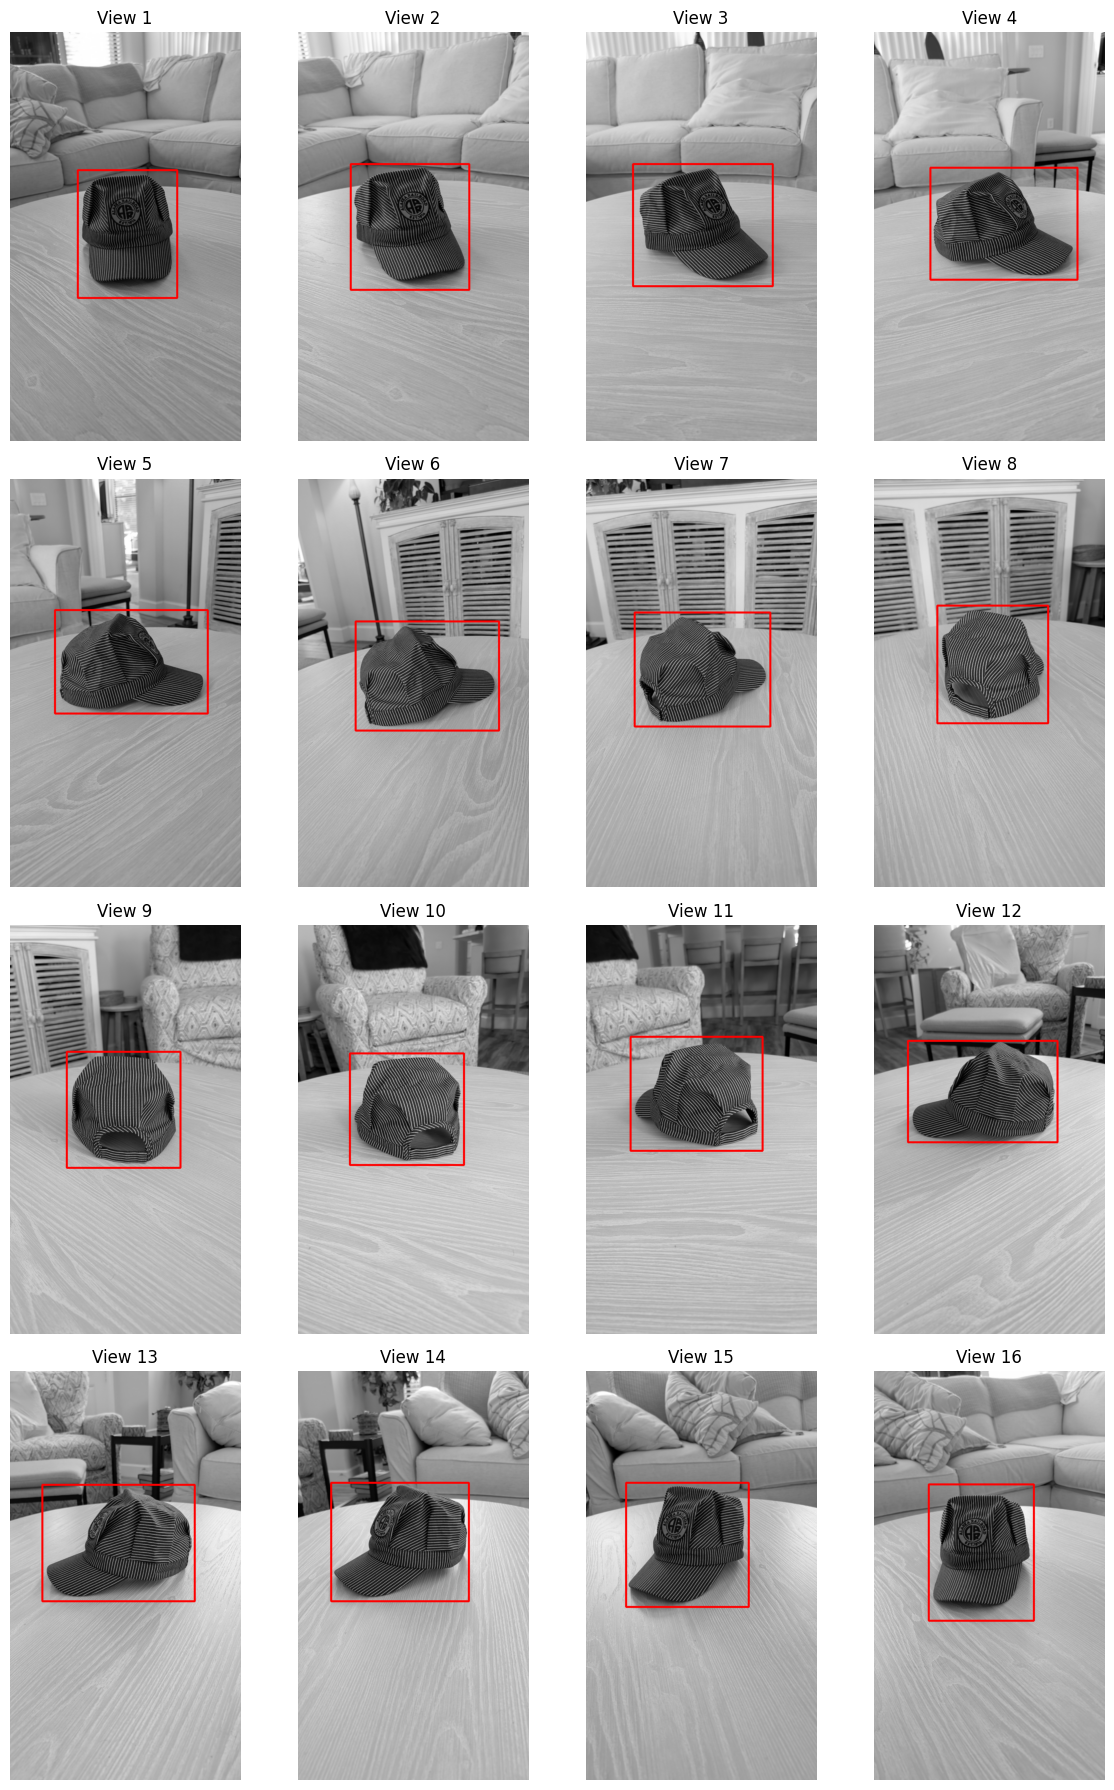

In [31]:
HAT_BOXES = [(166, 340, 410, 655), (129, 325, 420, 635), (115, 325, 458, 626), (138, 334, 499, 610),
             (110, 325, 485, 580), (141, 353, 493, 622), (119, 331, 452, 612), (155, 314, 427, 604),
             (139, 312, 418, 598), (127, 316, 407, 591), (109, 275, 433, 556), (83, 285, 450, 535),
             (79, 280, 453, 567), (81, 275, 419, 567), (98, 275, 399, 581), (134, 279, 392, 615)]

hat_masks = []
for img, (x0, y0, x1, y1) in zip(hat_images, HAT_BOXES):
    mask = np.zeros(img.shape, np.uint8)
    mask[y0:y1, x0:x1] = 255   # SIFT only looks where the mask is not zero
    hat_masks.append(mask)

fig, ax = plt.subplots(nrows=4, ncols=4)
fig.set_size_inches(12, 18)
for i, (x0, y0, x1, y1) in enumerate(HAT_BOXES):
    shown = cv2.cvtColor(hat_images[i], cv2.COLOR_GRAY2RGB)
    cv2.rectangle(shown, (x0, y0), (x1, y1), (255, 0, 0), 4)
    ax[i // 4, i % 4].imshow(shown)
    ax[i // 4, i % 4].set_title('View {}'.format(i + 1))
    ax[i // 4, i % 4].axis('off')
plt.tight_layout()

## SIFT keypoints and descriptors on the hat

Keypoints on the hat per view: [495 574 579 580 468 437 434 516 411 547 519 439 554 503 590 580]
Mean keypoints per view: 514

 Keypoint #5 (of 495) in view 1:
 angle=186.36, (octave, layer, scale)=-1.00 1.00 2.00, size=2.06, pt=(176.3477020263672, 450.3553466796875)

Descriptor matrix of view 1: (495, 128)


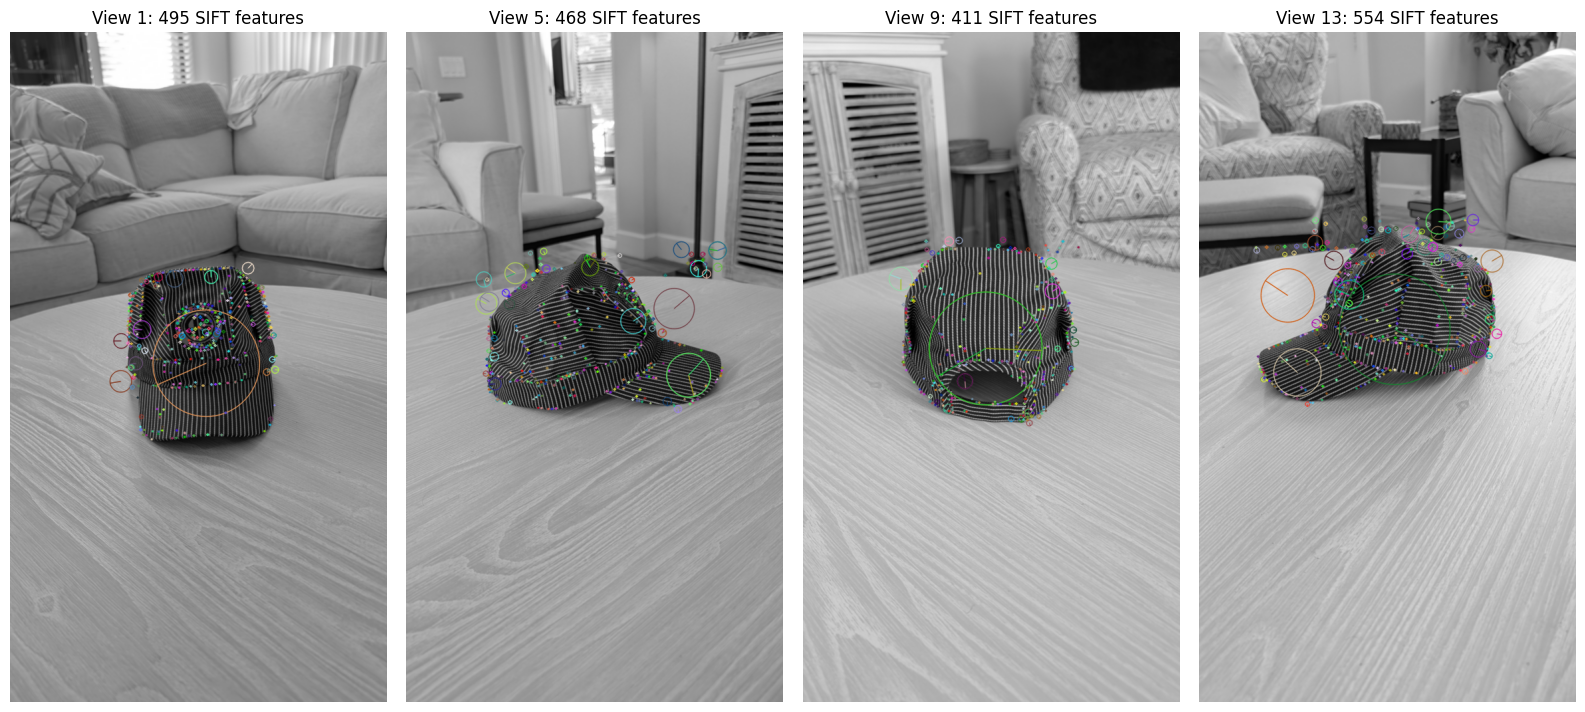

In [32]:
sift = cv2.SIFT_create()
keypoints, descriptors = [], []
for img, mask in zip(hat_images, hat_masks):
    kp, des = sift.detectAndCompute(img, mask)   # the mask limits SIFT to the hat
    keypoints.append(kp)
    descriptors.append(des)

num_kp = np.array([len(k) for k in keypoints])
print('Keypoints on the hat per view:', num_kp)
print('Mean keypoints per view: {:.0f}'.format(num_kp.mean()))

# Inspect one keypoint, as in the module notebook
i = 5
octave, layer, scale = unpackSIFTOctave(keypoints[0][i])
print('\n Keypoint #{} (of {}) in view 1:\n angle={:0.2f}, (octave, layer, scale)={:0.2f} {:0.2f} {:0.2f}, size={:0.2f}, pt={}\n'.format(
    i, len(keypoints[0]), keypoints[0][i].angle, octave, layer, scale, keypoints[0][i].size, keypoints[0][i].pt))
print('Descriptor matrix of view 1:', descriptors[0].shape)

fig, ax = plt.subplots(nrows=1, ncols=4)
fig.set_size_inches(16, 7)
for a, v in zip(ax, [0, 4, 8, 12]):
    a.imshow(cv2.drawKeypoints(hat_images[v], keypoints[v], None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS))
    a.set_title('View {}: {} SIFT features'.format(v + 1, len(keypoints[v])))
    a.axis('off')
plt.tight_layout()

## Matching with Lowe's ratio test

The module notebook matches with `cv2.BFMatcher(cv2.NORM_L1, crossCheck=True)` and notes that cross checking is an alternative to the ratio test used by D. Lowe in the SIFT paper. Here we use Lowe's ratio test with the same L1 matcher. For each keypoint in the first image, `knnMatch` with `k=2` finds its two nearest descriptors in the second image. If the best one (`m`) is clearly closer than the second best (`n`), the match is distinctive and kept; if they are about the same distance, the match is ambiguous (for example, two identical looking stripes) and thrown away. Lowe used a threshold of 0.8 and the OpenCV tutorial uses 0.75. A first run with 0.75 still let through visibly wrong matches, so this notebook uses a stricter **0.7**.

**Measures used to judge the detector.**
* **good matches**: number of matches that pass the ratio test
* **matching score**: good matches / keypoints in the view with fewer keypoints, the fraction of features that found a distinctive partner
* **mean distance**: average L1 descriptor distance of the good matches (lower means the matched patches look more alike)

# Matching with Lowe's Ratio


In [33]:
bf = cv2.BFMatcher(cv2.NORM_L1)   # the module's matcher, without crossCheck so that knnMatch can return 2 neighbours
RATIO = 0.7

def lowe_match(a, b):
    """Match view a to view b and keep the matches that pass Lowe's ratio test, best (lowest distance) first."""
    good = []
    for m, n in bf.knnMatch(descriptors[a], descriptors[b], k=2):
        if m.distance < RATIO * n.distance:
            good.append(m)
    return sorted(good, key=lambda x: x.distance)

def view_angle(a, b):
    """Viewpoint change in degrees between two views on the circle (0 to 180)."""
    d = abs(a - b)
    return min(d, N_VIEWS - d) * STEP_DEG

# Comparing each image to its immediate neighboring images

Each perspective of the hat is matched with its neighboring perspective images. Each image is taken roguhly 22.5 degrees apart around the circular table which holds the hat in its center.

The number of matches is displayed at the top, and the top 10 matches are drawn onto the images.

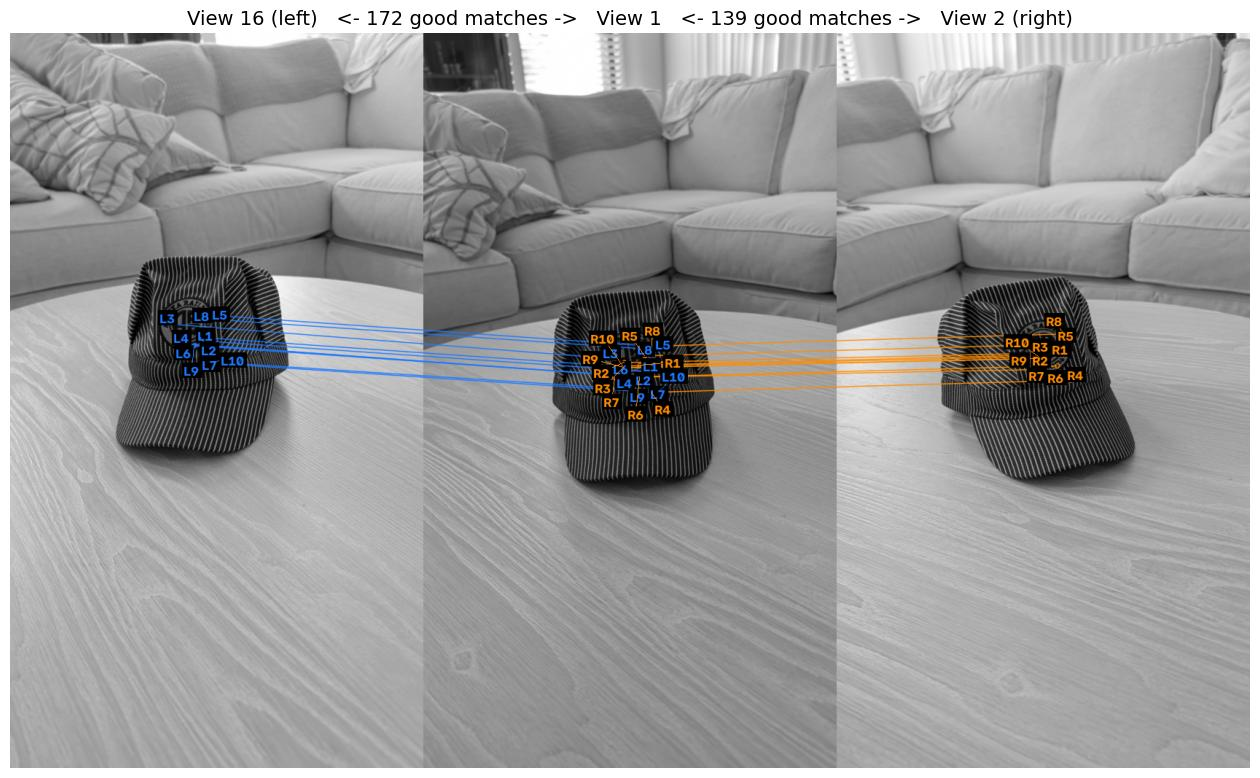

   #  neighbour   dist    view 1 (x, y)   neighbour (x, y)
  L1    view 16    245       (306, 464)         (262, 422)
  L2    view 16    282       (304, 459)         (260, 417)
  L3    view 16    300       (250, 445)         (209, 398)
  L4    view 16    303       (274, 470)         (229, 425)
  L5    view 16    309       (323, 434)         (282, 392)
  L6    view 16    310       (274, 470)         (229, 425)
  L7    view 16    313       (312, 492)         (265, 452)
  L8    view 16    315       (314, 429)         (274, 386)
  L9    view 16    321       (297, 471)         (252, 428)
 L10    view 16    325       (325, 491)         (278, 451)
  R1     view 2    369       (297, 455)         (300, 440)
  R2     view 2    372       (275, 452)         (278, 439)
  R3     view 2    386       (275, 458)         (279, 446)
  R4     view 2    395       (312, 492)         (321, 476)
  R5     view 2    398       (304, 442)         (304, 426)
  R6     view 2    401       (297, 471)         (302, 45

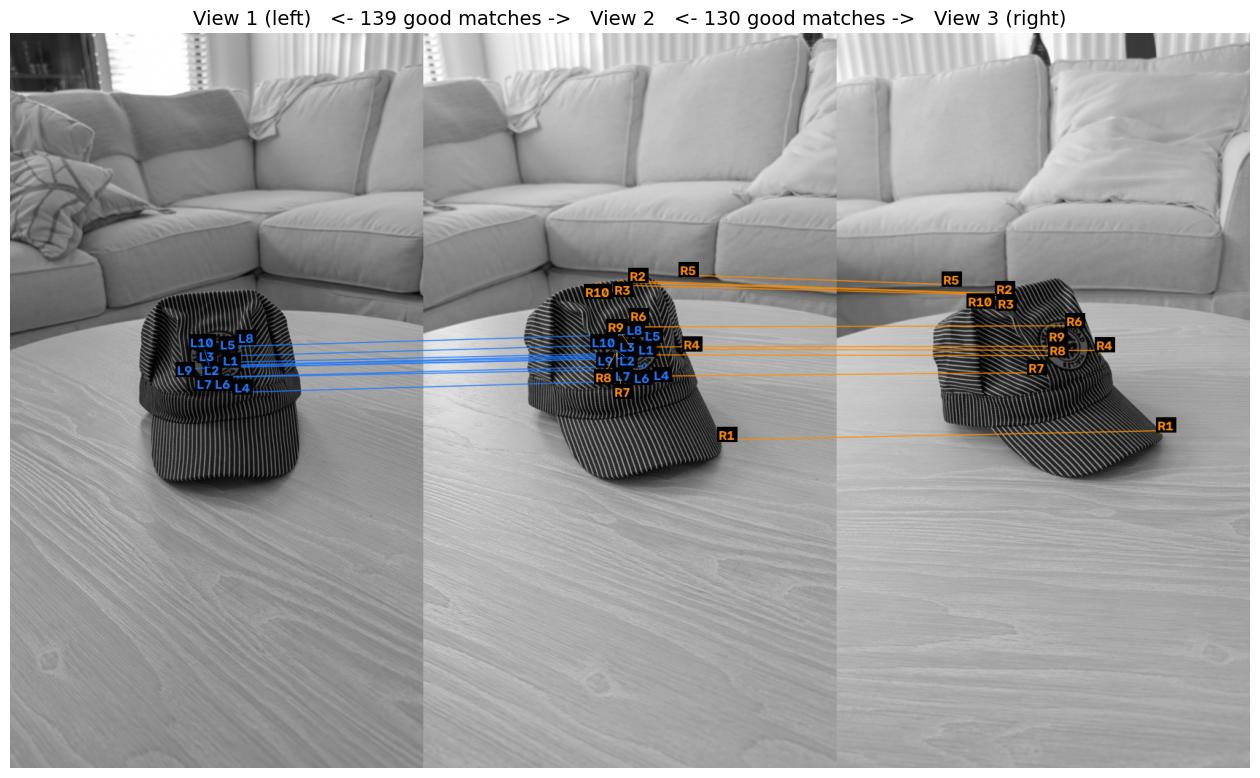

   #  neighbour   dist    view 2 (x, y)   neighbour (x, y)
  L1     view 1    369       (300, 440)         (297, 455)
  L2     view 1    372       (278, 439)         (275, 452)
  L3     view 1    386       (279, 446)         (275, 458)
  L4     view 1    395       (321, 476)         (312, 492)
  L5     view 1    398       (304, 426)         (304, 442)
  L6     view 1    401       (302, 456)         (297, 471)
  L7     view 1    404       (269, 461)         (262, 472)
  L8     view 1    404       (312, 412)         (314, 429)
  L9     view 1    414       (279, 446)         (275, 458)
 L10     view 1    416       (276, 443)         (273, 456)
  R1     view 3    385       (410, 558)         (445, 545)
  R2     view 3    464       (288, 340)         (223, 357)
  R3     view 3    468       (271, 341)         (223, 357)
  R4     view 3    501       (362, 433)         (361, 435)
  R5     view 3    510       (357, 331)         (150, 344)
  R6     view 3    530       (300, 403)         (320, 40

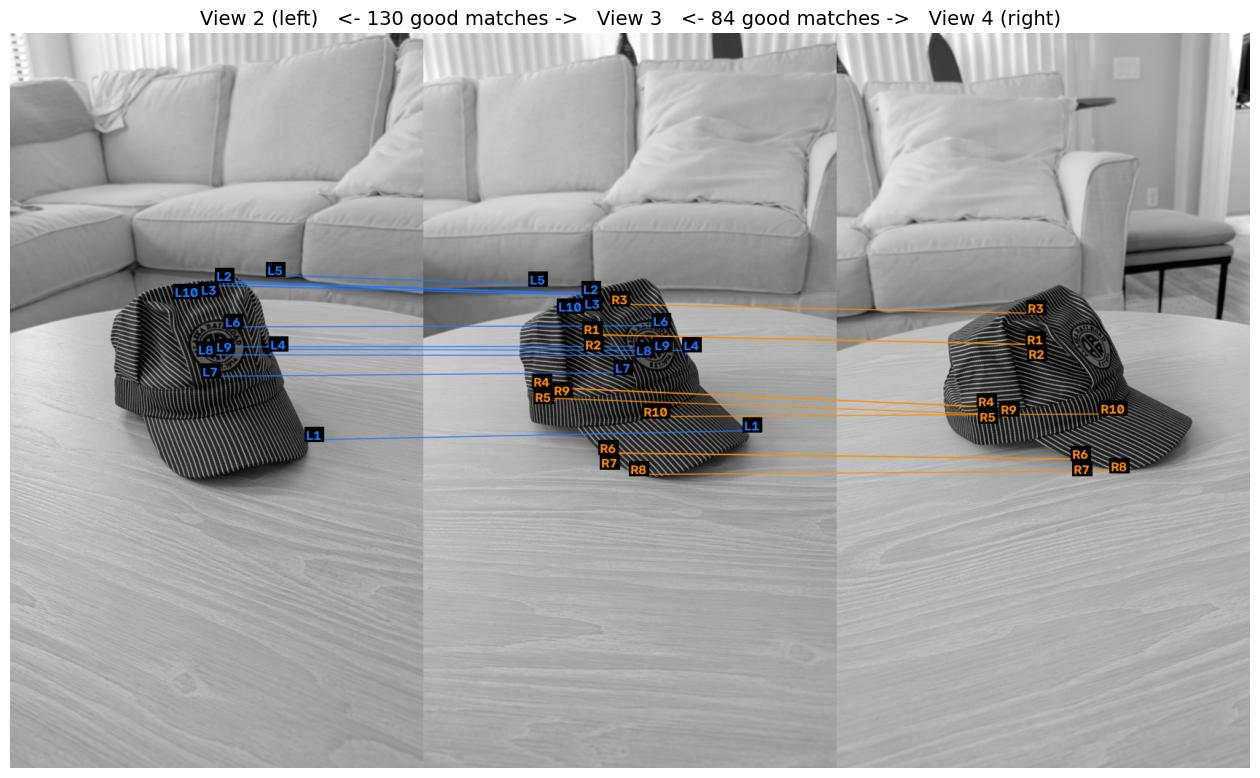

   #  neighbour   dist    view 3 (x, y)   neighbour (x, y)
  L1     view 2    385       (445, 545)         (410, 558)
  L2     view 2    464       (223, 357)         (288, 340)
  L3     view 2    468       (223, 357)         (271, 341)
  L4     view 2    501       (361, 435)         (362, 433)
  L5     view 2    510       (150, 344)         (357, 331)
  L6     view 2    530       (320, 401)         (300, 403)
  L7     view 2    538       (268, 466)         (269, 470)
  L8     view 2    583       (297, 442)         (262, 441)
  L9     view 2    589       (312, 429)         (284, 430)
 L10     view 2    603       (218, 359)         (241, 345)
  R1     view 4    112       (225, 413)         (266, 427)
  R2     view 4    143       (225, 413)         (266, 427)
  R3     view 4    359       (262, 371)         (267, 384)
  R4     view 4    368       (156, 485)         (199, 512)
  R5     view 4    374       (156, 485)         (199, 512)
  R6     view 4    379       (247, 575)         (328, 58

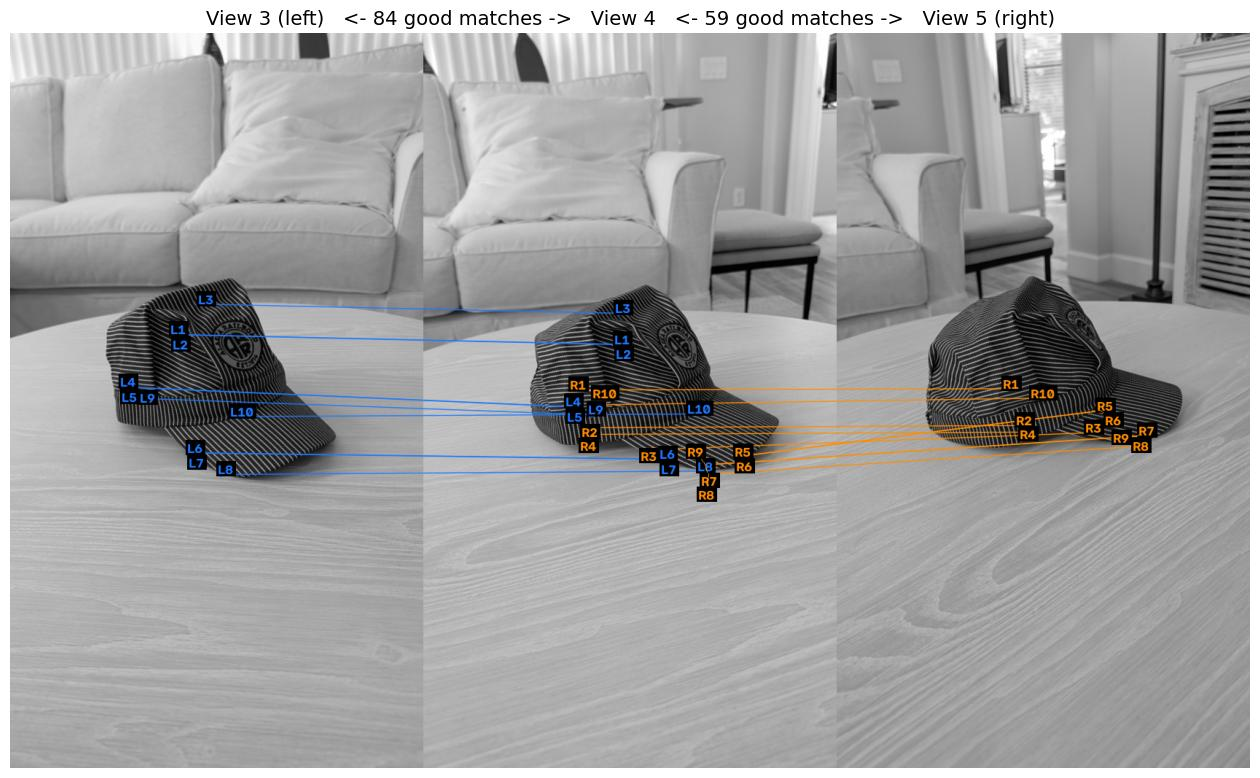

   #  neighbour   dist    view 4 (x, y)   neighbour (x, y)
  L1     view 3    112       (266, 427)         (225, 413)
  L2     view 3    143       (266, 427)         (225, 413)
  L3     view 3    359       (267, 384)         (262, 371)
  L4     view 3    368       (199, 512)         (156, 485)
  L5     view 3    374       (199, 512)         (156, 485)
  L6     view 3    379       (328, 584)         (247, 575)
  L7     view 3    402       (328, 584)         (247, 575)
  L8     view 3    520       (381, 600)         (289, 605)
  L9     view 3    528       (230, 523)         (180, 501)
 L10     view 3    536       (372, 522)         (312, 526)
  R1     view 5    116       (206, 489)         (233, 487)
  R2     view 5    148       (221, 541)         (251, 538)
  R3     view 5    155       (315, 571)         (346, 548)
  R4     view 5    176       (223, 550)         (253, 547)
  R5     view 5    287       (432, 580)         (362, 517)
  R6     view 5    296       (432, 580)         (362, 51

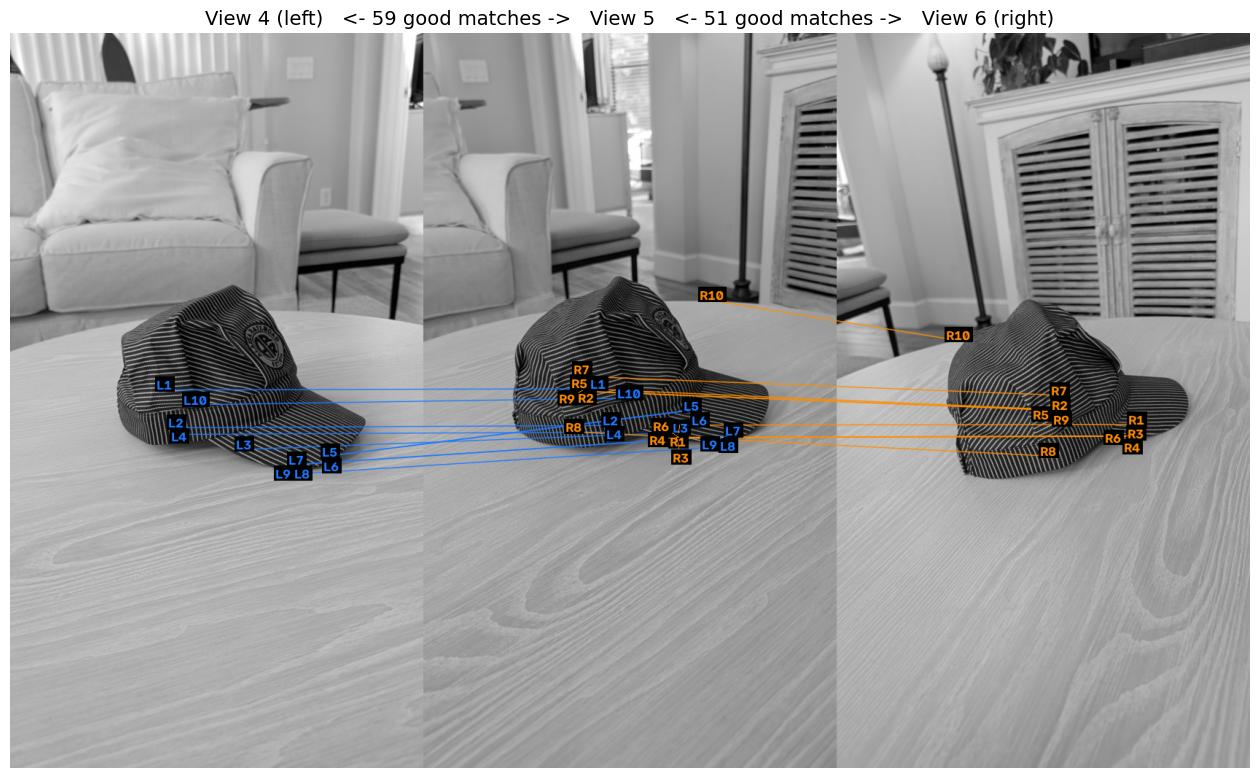

   #  neighbour   dist    view 5 (x, y)   neighbour (x, y)
  L1     view 4    116       (233, 487)         (206, 489)
  L2     view 4    148       (251, 538)         (221, 541)
  L3     view 4    155       (346, 548)         (315, 571)
  L4     view 4    176       (253, 547)         (223, 550)
  L5     view 4    287       (362, 517)         (432, 580)
  L6     view 4    296       (362, 517)         (432, 580)
  L7     view 4    308       (419, 552)         (387, 592)
  L8     view 4    322       (408, 567)         (392, 604)
  L9     view 4    325       (419, 552)         (387, 592)
 L10     view 4    352       (276, 500)         (248, 509)
  R1     view 6    198       (352, 537)         (405, 536)
  R2     view 6    265       (218, 491)         (300, 517)
  R3     view 6    288       (347, 554)         (402, 552)
  R4     view 6    289       (350, 555)         (402, 552)
  R5     view 6    303       (208, 487)         (288, 516)
  R6     view 6    306       (350, 555)         (402, 55

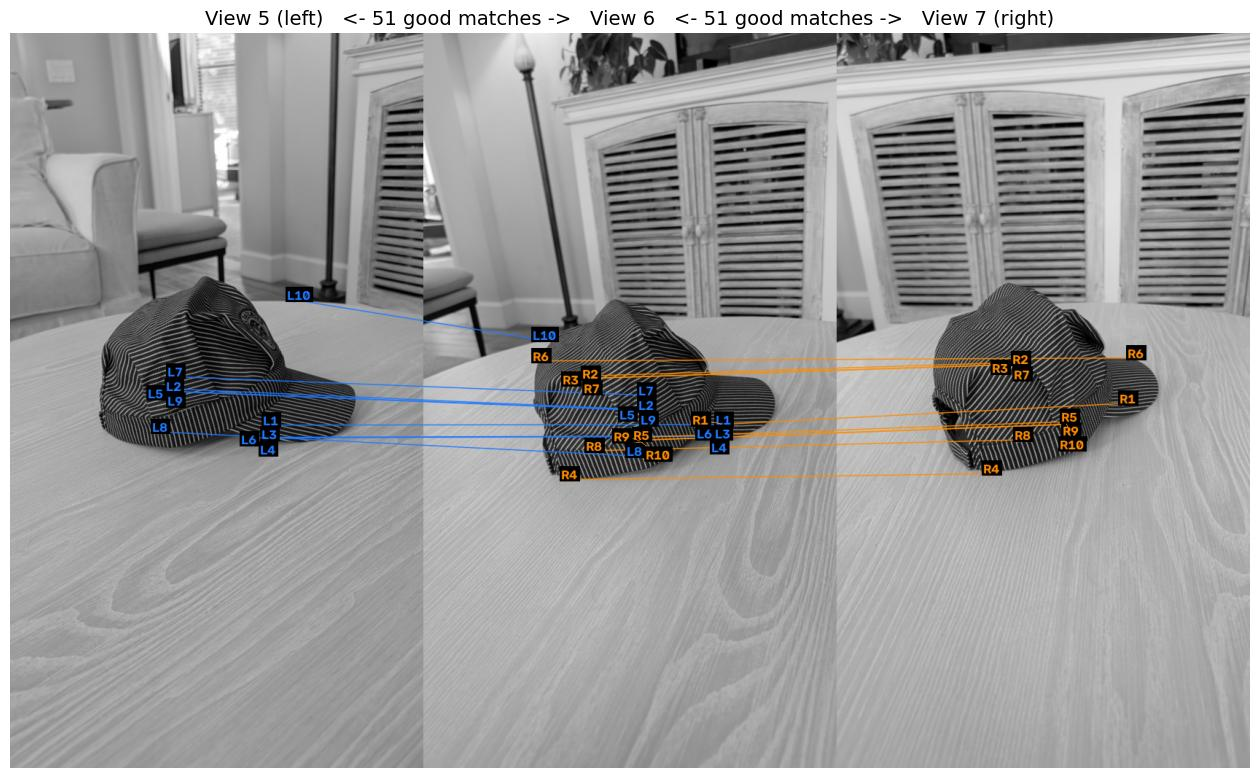

   #  neighbour   dist    view 6 (x, y)   neighbour (x, y)
  L1     view 5    198       (405, 536)         (352, 537)
  L2     view 5    265       (300, 517)         (218, 491)
  L3     view 5    288       (402, 552)         (347, 554)
  L4     view 5    289       (402, 552)         (350, 555)
  L5     view 5    303       (288, 516)         (208, 487)
  L6     view 5    306       (402, 552)         (350, 555)
  L7     view 5    319       (299, 496)         (221, 471)
  L8     view 5    320       (284, 579)         (200, 546)
  L9     view 5    365       (300, 517)         (218, 491)
 L10     view 5    385       (160, 420)         (390, 365)
  R1     view 7    203       (408, 536)         (392, 508)
  R2     view 7    299       (223, 473)         (246, 454)
  R3     view 7    300       (212, 470)         (232, 452)
  R4     view 7    377       (194, 612)         (206, 604)
  R5     view 7    397       (291, 554)         (313, 533)
  R6     view 7    401       (155, 449)         (404, 44

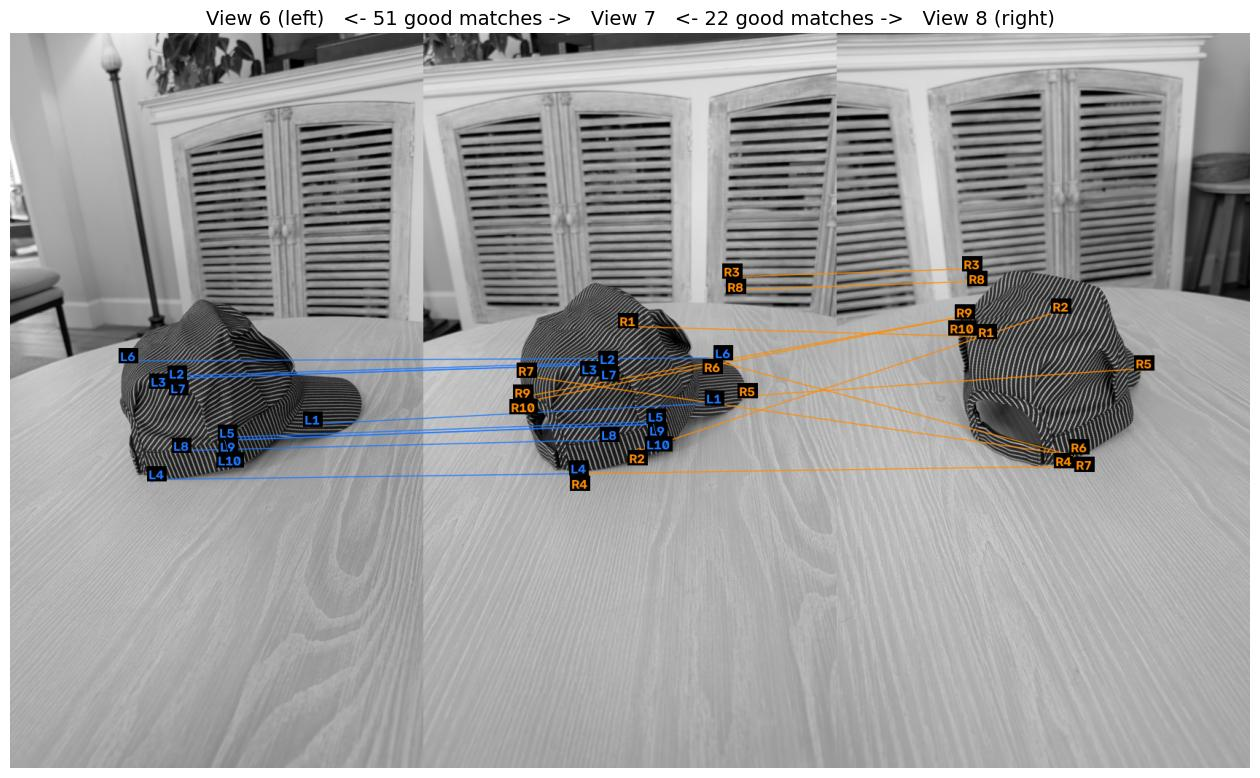

   #  neighbour   dist    view 7 (x, y)   neighbour (x, y)
  L1     view 6    203       (392, 508)         (408, 536)
  L2     view 6    299       (246, 454)         (223, 473)
  L3     view 6    300       (232, 452)         (212, 470)
  L4     view 6    377       (206, 604)         (194, 612)
  L5     view 6    397       (313, 533)         (291, 554)
  L6     view 6    401       (404, 445)         (155, 449)
  L7     view 6    406       (246, 454)         (223, 473)
  L8     view 6    410       (249, 557)         (228, 572)
  L9     view 6    434       (316, 536)         (294, 558)
 L10     view 6    449       (316, 536)         (294, 558)
  R1     view 8    208       (274, 402)         (199, 416)
  R2     view 8    221       (295, 572)         (301, 382)
  R3     view 8    254       (417, 334)         (179, 323)
  R4     view 8    372       (206, 604)         (305, 594)
  R5     view 8    598       (437, 498)         (415, 460)
  R6     view 8    632       (394, 448)         (322, 57

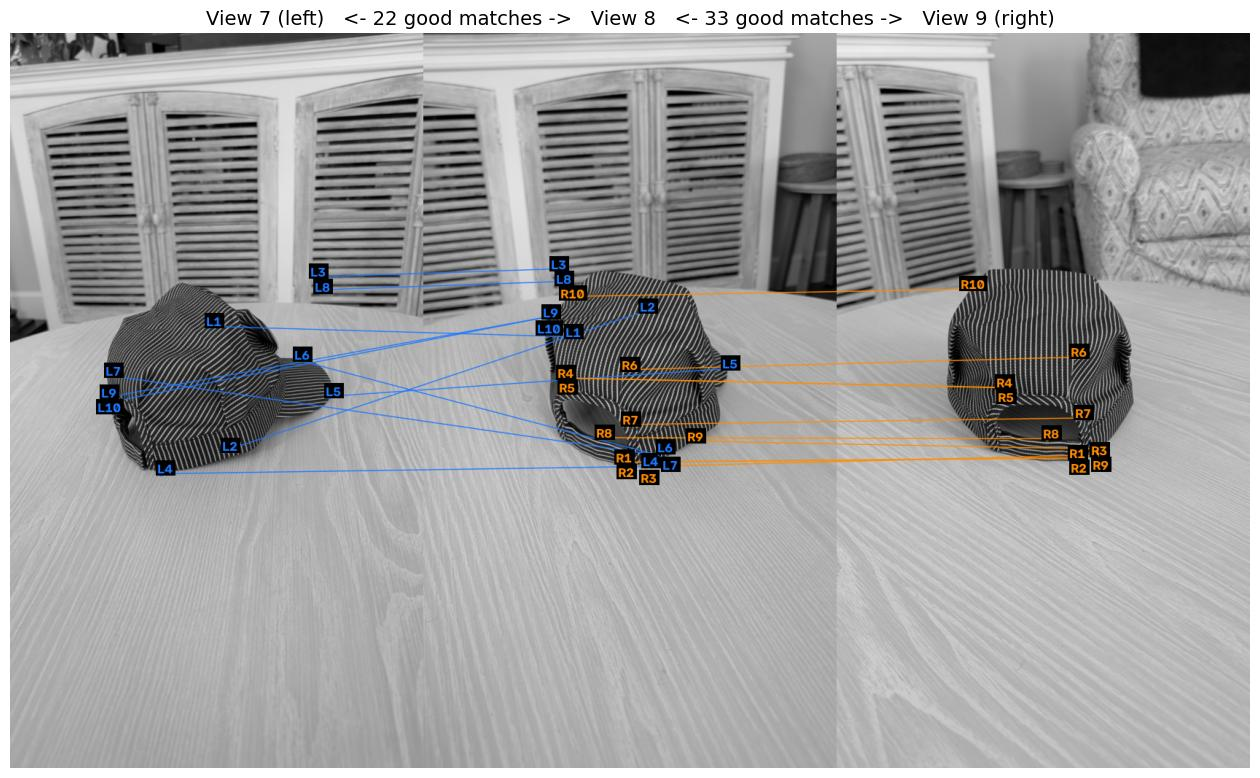

   #  neighbour   dist    view 8 (x, y)   neighbour (x, y)
  L1     view 7    208       (199, 416)         (274, 402)
  L2     view 7    221       (301, 382)         (295, 572)
  L3     view 7    254       (179, 323)         (417, 334)
  L4     view 7    372       (305, 594)         (206, 604)
  L5     view 7    598       (415, 460)         (437, 498)
  L6     view 7    632       (322, 579)         (394, 448)
  L7     view 7    668       (322, 579)         (135, 469)
  L8     view 7    682       (184, 340)         (420, 352)
  L9     view 7    733       (168, 389)         (130, 500)
 L10     view 7    772       (168, 389)         (129, 507)
  R1     view 9    392       (269, 588)         (324, 582)
  R2     view 9    394       (269, 588)         (324, 582)
  R3     view 9    454       (305, 594)         (354, 578)
  R4     view 9    473       (189, 472)         (224, 486)
  R5     view 9    514       (189, 472)         (224, 486)
  R6     view 9    677       (277, 461)         (326, 44

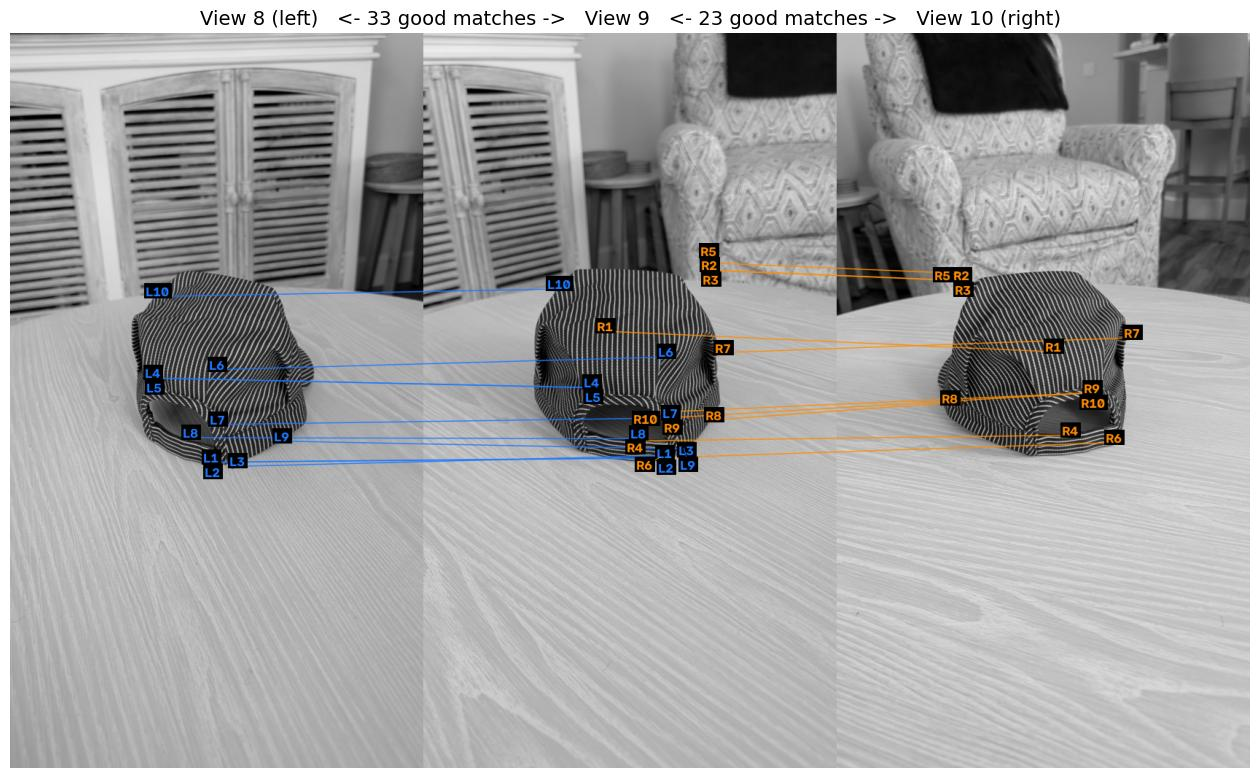

   #  neighbour   dist    view 9 (x, y)   neighbour (x, y)
  L1     view 8    392       (324, 582)         (269, 588)
  L2     view 8    394       (324, 582)         (269, 588)
  L3     view 8    454       (354, 578)         (305, 594)
  L4     view 8    473       (224, 486)         (189, 472)
  L5     view 8    514       (224, 486)         (189, 472)
  L6     view 8    677       (326, 444)         (277, 461)
  L7     view 8    682       (332, 527)         (278, 537)
  L8     view 8    690       (288, 556)         (241, 554)
  L9     view 8    735       (358, 570)         (367, 559)
 L10     view 8    787       (180, 351)         (196, 361)
  R1    view 10    219       (243, 408)         (291, 436)
  R2    view 10    315       (386, 324)         (165, 339)
  R3    view 10    407       (386, 324)         (165, 339)
  R4    view 10    473       (285, 559)         (314, 551)
  R5    view 10    490       (391, 315)         (168, 329)
  R6    view 10    546       (324, 582)         (374, 56

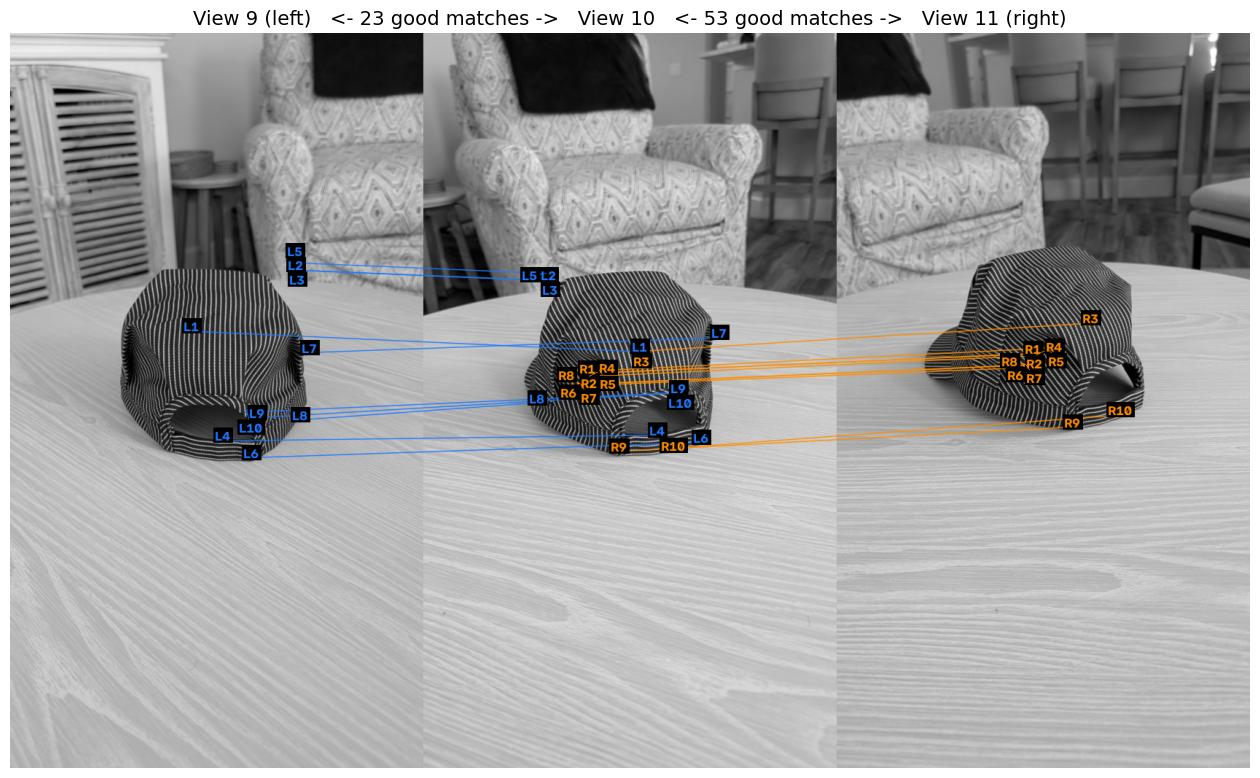

   #  neighbour   dist   view 10 (x, y)   neighbour (x, y)
  L1     view 9    219       (291, 436)         (243, 408)
  L2     view 9    315       (165, 339)         (386, 324)
  L3     view 9    407       (165, 339)         (386, 324)
  L4     view 9    473       (314, 551)         (285, 559)
  L5     view 9    490       (168, 329)         (391, 315)
  L6     view 9    546       (374, 561)         (324, 582)
  L7     view 9    678       (399, 418)         (405, 438)
  L8     view 9    700       (149, 507)         (392, 531)
  L9     view 9    762       (344, 493)         (332, 527)
 L10     view 9    791       (344, 493)         (326, 520)
  R1    view 11    167       (219, 467)         (263, 439)
  R2    view 11    183       (219, 467)         (263, 439)
  R3    view 11    192       (291, 436)         (341, 398)
  R4    view 11    209       (228, 470)         (273, 442)
  R5    view 11    232       (241, 463)         (289, 432)
  R6    view 11    258       (204, 484)         (247, 45

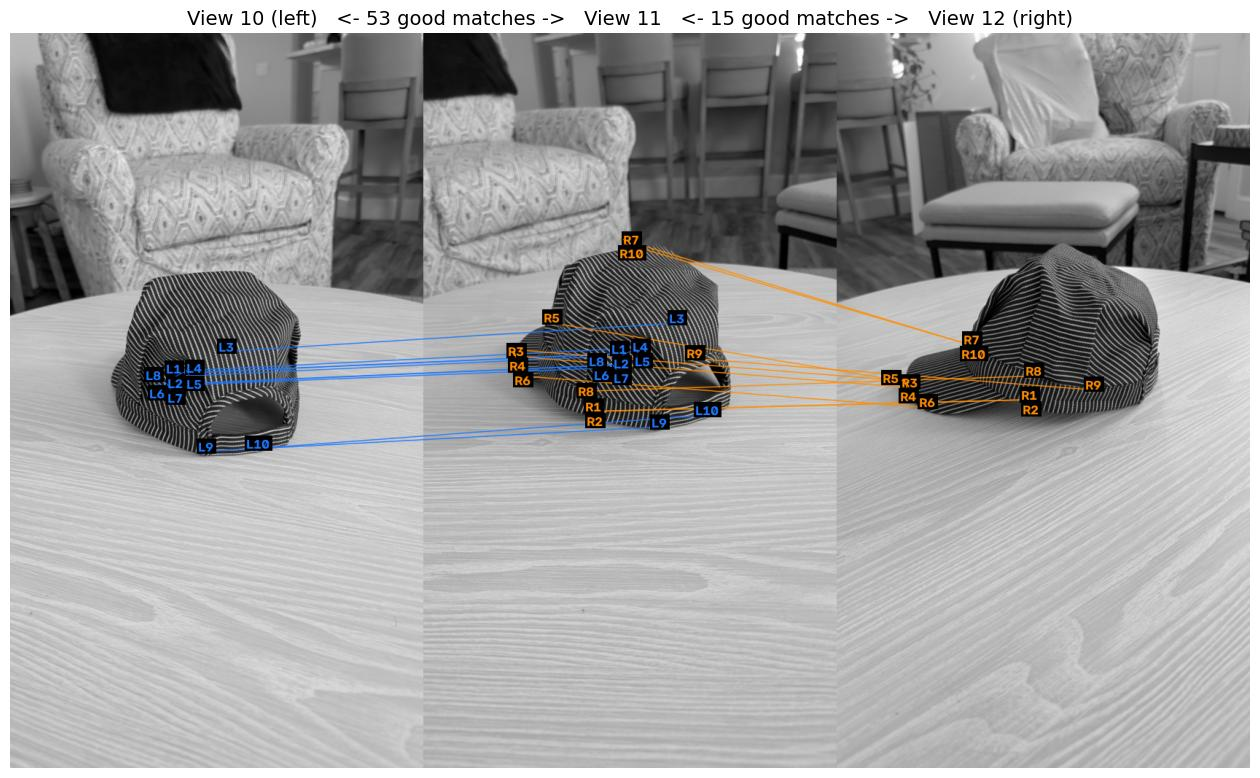

   #  neighbour   dist   view 11 (x, y)   neighbour (x, y)
  L1    view 10    167       (263, 439)         (219, 467)
  L2    view 10    183       (263, 439)         (219, 467)
  L3    view 10    192       (341, 398)         (291, 436)
  L4    view 10    209       (273, 442)         (228, 470)
  L5    view 10    232       (289, 432)         (241, 463)
  L6    view 10    258       (247, 459)         (204, 484)
  L7    view 10    259       (259, 455)         (215, 481)
  L8    view 10    268       (259, 455)         (215, 481)
  L9    view 10    378       (317, 540)         (262, 574)
 L10    view 10    404       (383, 524)         (334, 569)
  R1    view 12    439       (227, 519)         (258, 502)
  R2    view 12    467       (227, 519)         (258, 502)
  R3    view 12    584       (121, 443)          (94, 485)
  R4    view 12    608       (124, 434)          (93, 477)
  R5    view 12    792       (170, 396)          (96, 478)
  R6    view 12    858       (129, 469)         (117, 51

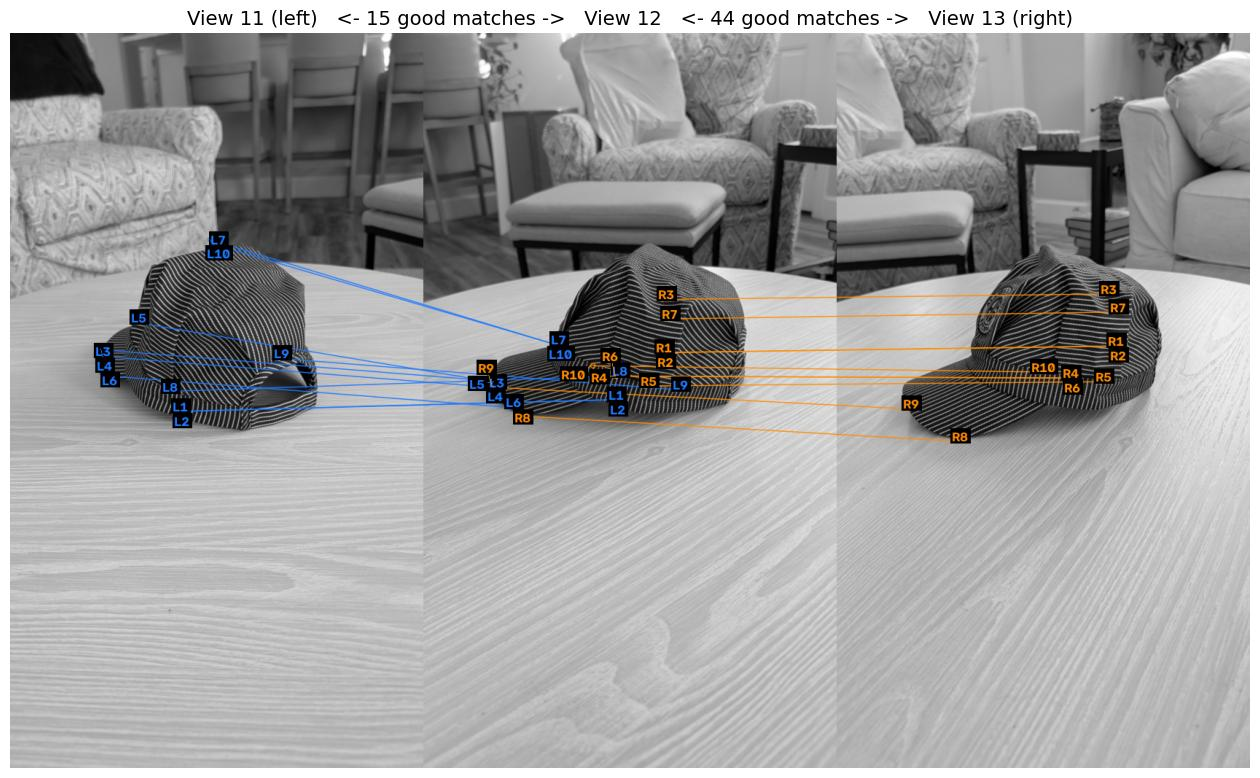

   #  neighbour   dist   view 12 (x, y)   neighbour (x, y)
  L1    view 11    439       (258, 502)         (227, 519)
  L2    view 11    467       (258, 502)         (227, 519)
  L3    view 11    584        (94, 485)         (121, 443)
  L4    view 11    608        (93, 477)         (124, 434)
  L5    view 11    792        (96, 478)         (170, 396)
  L6    view 11    858       (117, 513)         (129, 469)
  L7    view 11   1055       (179, 426)         (279, 289)
  L8    view 11   1094       (264, 470)         (214, 491)
  L9    view 11   1234       (346, 489)         (366, 446)
 L10    view 11   1323       (179, 426)         (274, 283)
  R1    view 13    144       (324, 438)         (377, 429)
  R2    view 13    150       (324, 438)         (377, 429)
  R3    view 13    358       (327, 365)         (367, 357)
  R4    view 13    418       (264, 470)         (315, 473)
  R5    view 13    424       (303, 484)         (360, 478)
  R6    view 13    430       (264, 470)         (315, 47

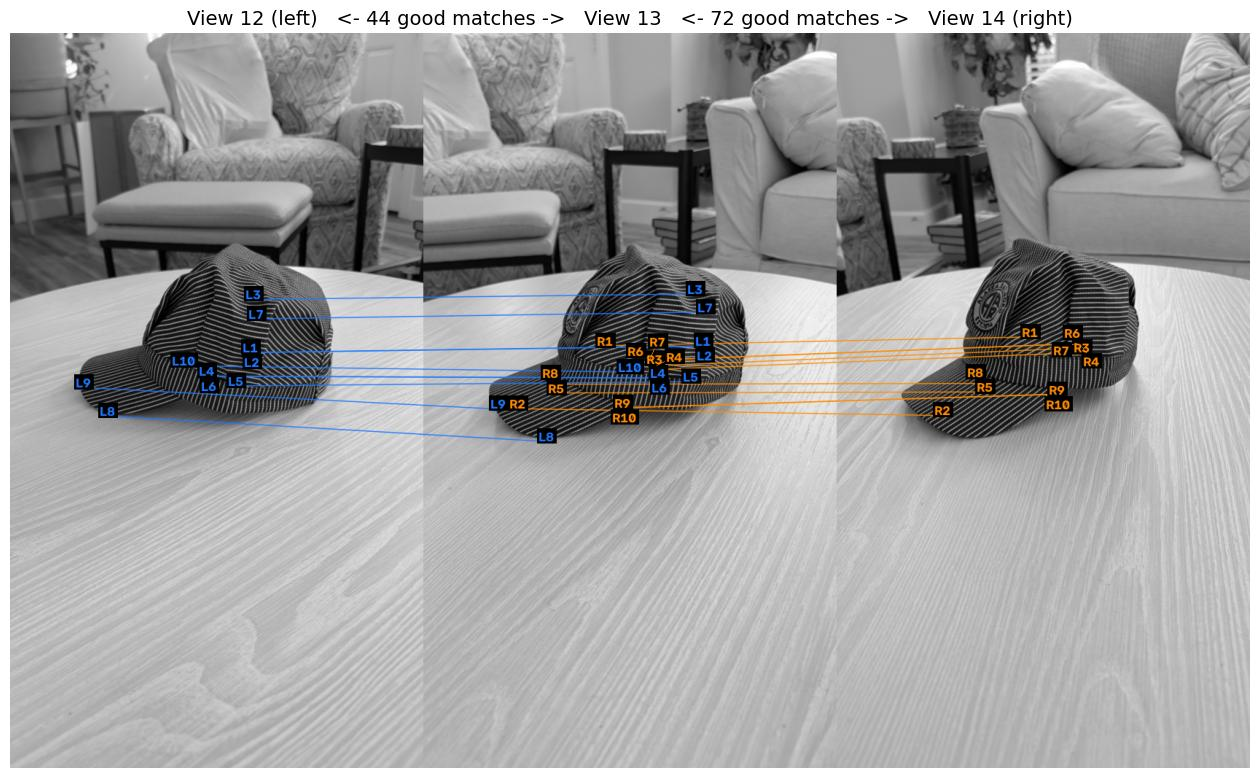

   #  neighbour   dist   view 13 (x, y)   neighbour (x, y)
  L1    view 12    144       (377, 429)         (324, 438)
  L2    view 12    150       (377, 429)         (324, 438)
  L3    view 12    358       (367, 357)         (327, 365)
  L4    view 12    418       (315, 473)         (264, 470)
  L5    view 12    424       (360, 478)         (303, 484)
  L6    view 12    430       (315, 473)         (264, 470)
  L7    view 12    445       (380, 382)         (332, 392)
  L8    view 12    452       (163, 559)         (127, 524)
  L9    view 12    454        (96, 515)          (94, 485)
 L10    view 12    461       (277, 464)         (232, 456)
  R1    view 14    113       (242, 428)         (259, 416)
  R2    view 14    144       (115, 515)         (138, 524)
  R3    view 14    144       (311, 461)         (330, 438)
  R4    view 14    147       (320, 456)         (338, 431)
  R5    view 14    166       (176, 493)         (197, 492)
  R6    view 14    167       (310, 448)         (328, 42

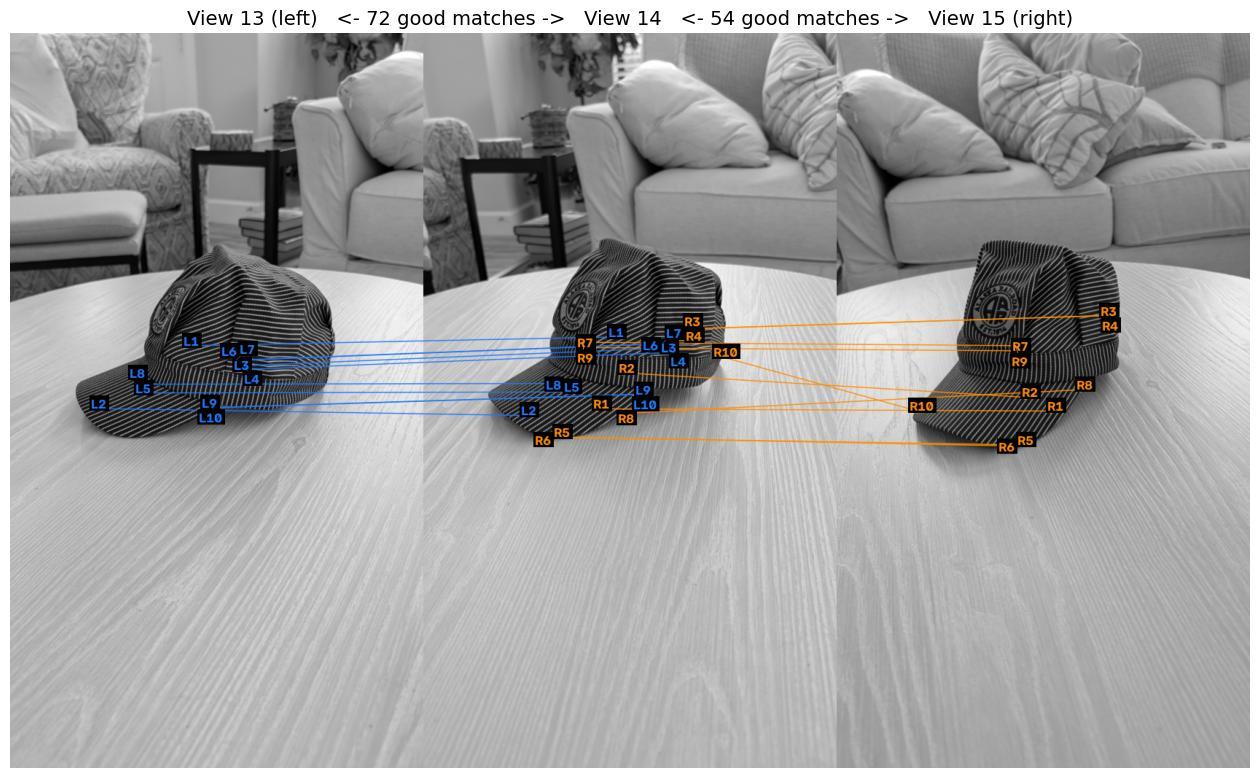

   #  neighbour   dist   view 14 (x, y)   neighbour (x, y)
  L1    view 13    113       (259, 416)         (242, 428)
  L2    view 13    144       (138, 524)         (115, 515)
  L3    view 13    144       (330, 438)         (311, 461)
  L4    view 13    147       (338, 431)         (320, 456)
  L5    view 13    166       (197, 492)         (176, 493)
  L6    view 13    167       (328, 426)         (310, 448)
  L7    view 13    172       (328, 426)         (310, 448)
  L8    view 13    186       (195, 480)         (179, 481)
  L9    view 13    222       (296, 495)         (267, 514)
 L10    view 13    225       (296, 495)         (267, 514)
  R1    view 15    156       (238, 515)         (293, 518)
  R2    view 15    178       (273, 465)         (259, 499)
  R3    view 15    189       (359, 405)         (367, 387)
  R4    view 15    190       (359, 405)         (367, 387)
  R5    view 15    389       (184, 554)         (253, 564)
  R6    view 15    399       (174, 553)         (244, 56

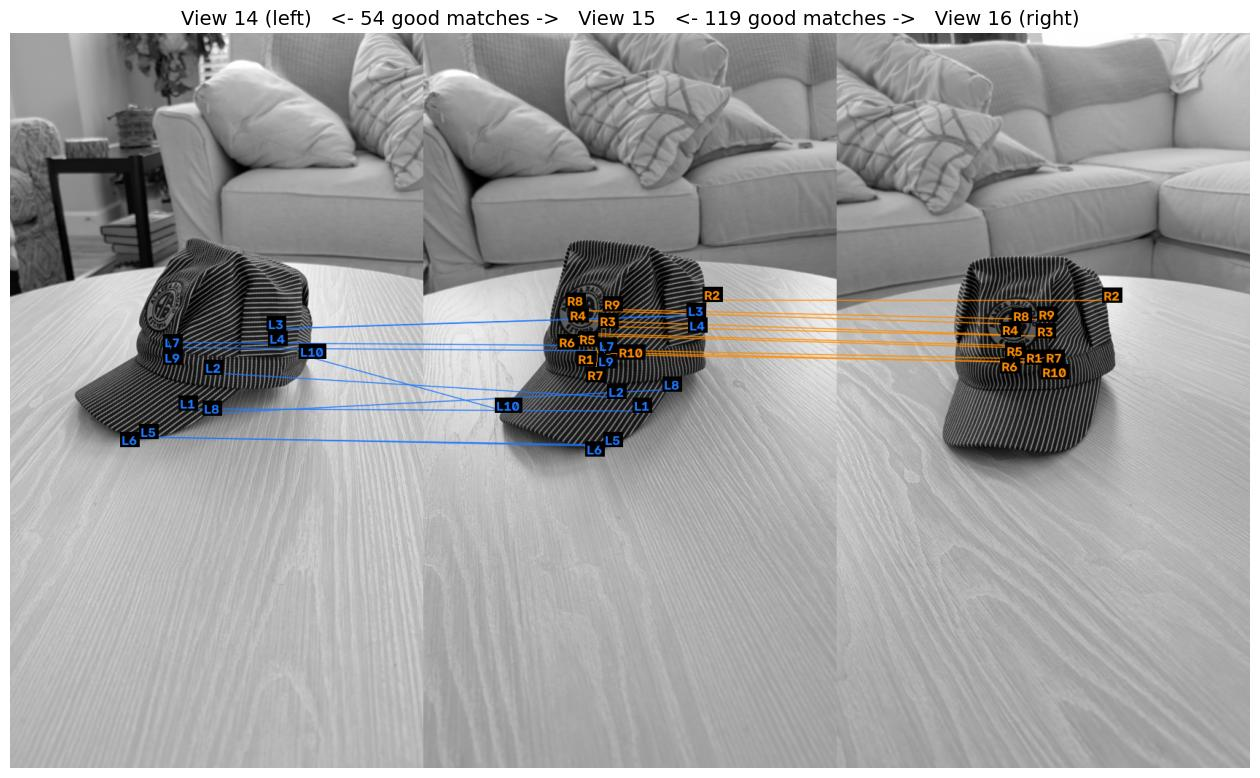

   #  neighbour   dist   view 15 (x, y)   neighbour (x, y)
  L1    view 14    156       (293, 518)         (238, 515)
  L2    view 14    178       (259, 499)         (273, 465)
  L3    view 14    189       (367, 387)         (359, 405)
  L4    view 14    190       (367, 387)         (359, 405)
  L5    view 14    389       (253, 564)         (184, 554)
  L6    view 14    399       (244, 566)         (174, 553)
  L7    view 14    459       (246, 435)         (216, 431)
  L8    view 14    478       (334, 489)         (271, 521)
  L9    view 14    528       (246, 428)         (217, 424)
 L10    view 14    571       (110, 518)         (408, 443)
  R1    view 16    431       (228, 437)         (265, 452)
  R2    view 16    498       (390, 366)         (371, 366)
  R3    view 16    529       (247, 402)         (280, 415)
  R4    view 16    571       (206, 393)         (231, 413)
  R5    view 16    578       (221, 412)         (252, 428)
  R6    view 16    588       (218, 414)         (249, 43

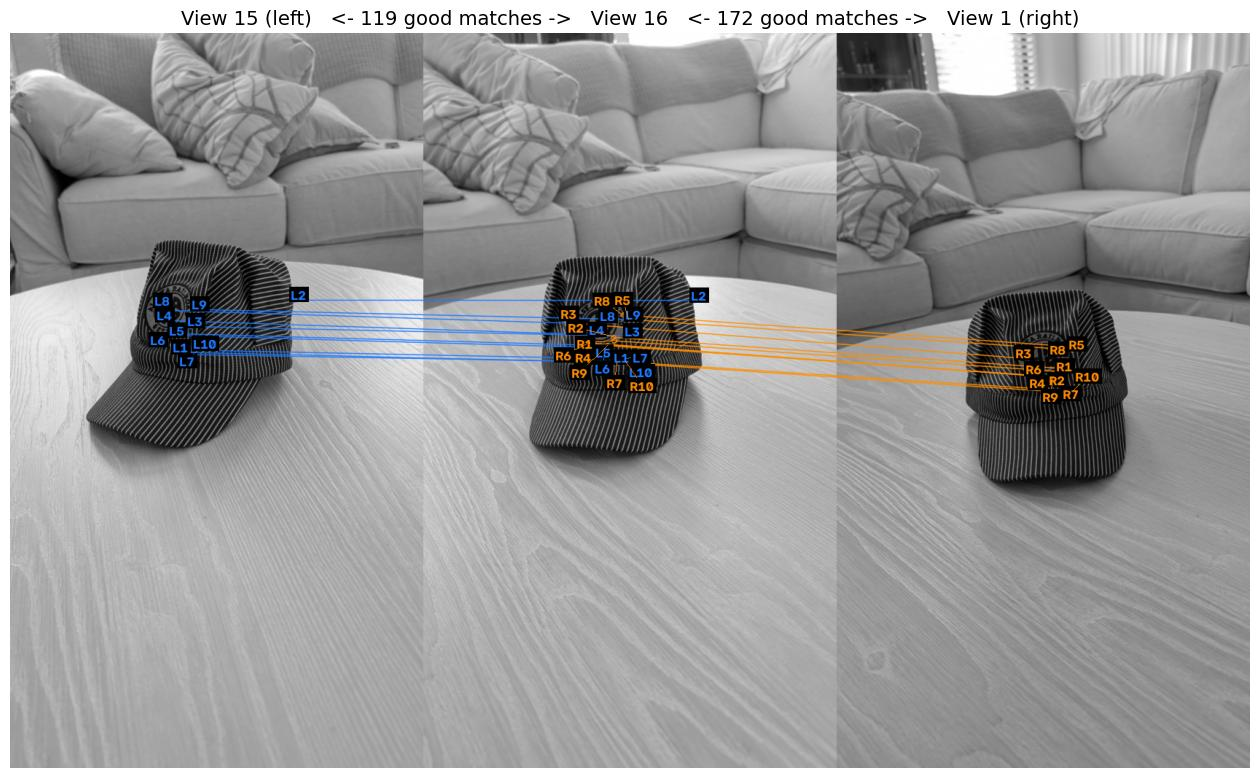

   #  neighbour   dist   view 16 (x, y)   neighbour (x, y)
  L1    view 15    431       (265, 452)         (228, 437)
  L2    view 15    498       (371, 366)         (390, 366)
  L3    view 15    529       (280, 415)         (247, 402)
  L4    view 15    571       (231, 413)         (206, 393)
  L5    view 15    578       (252, 428)         (221, 412)
  L6    view 15    588       (249, 431)         (218, 414)
  L7    view 15    612       (277, 447)         (240, 434)
  L8    view 15    618       (242, 399)         (219, 380)
  L9    view 15    624       (282, 392)         (253, 379)
 L10    view 15    629       (290, 451)         (252, 441)
  R1     view 1    245       (262, 422)         (306, 464)
  R2     view 1    282       (260, 417)         (304, 459)
  R3     view 1    300       (209, 398)         (250, 445)
  R4     view 1    303       (229, 425)         (274, 470)
  R5     view 1    309       (282, 392)         (323, 434)
  R6     view 1    310       (229, 425)         (274, 47

In [34]:
N_SHOW = 10
LEFT_COLOR, RIGHT_COLOR = (30, 120, 255), (255, 140, 0)

def place_labels(img, labels):
    """Display only: write each label near its point without overlapping another label.
    labels: list of (text, (x, y), color, (x_min, x_max)); each label stays inside its own photo."""
    placed = []
    for text, (px, py), color, (x_min, x_max) in labels:
        (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        box = None
        for r in range(10, 600, 6):                     # try spots on growing circles around the point
            for ang in np.deg2rad(np.arange(-45, 315, 20)):
                cx, cy = px + r * np.cos(ang), py + r * np.sin(ang)
                cand = (int(cx - tw / 2), int(cy - th / 2), int(cx + tw / 2), int(cy + th / 2))
                inside = x_min <= cand[0] and cand[2] <= x_max and 0 <= cand[1] and cand[3] <= img.shape[0]
                free = all(cand[2] + 3 <= p[0] or p[2] + 3 <= cand[0] or cand[3] + 3 <= p[1] or p[3] + 3 <= cand[1]
                           for p in placed)
                if inside and free:
                    box = cand
                    break
            if box is not None:
                break
        placed.append(box)
        if r > 16:   # the label had to move away from its point, so connect them
            cv2.line(img, (int(px), int(py)), ((box[0] + box[2]) // 2, (box[1] + box[3]) // 2), color, 1)
        cv2.rectangle(img, (box[0] - 2, box[1] - 2), (box[2] + 2, box[3] + 2), (0, 0, 0), -1)
        cv2.putText(img, text, (box[0], box[3]), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

def show_neighbours(c):
    left, right = (c - 1) % N_VIEWS, (c + 1) % N_VIEWS
    good_left = lowe_match(left, c)     # left neighbour -> hat
    good_right = lowe_match(c, right)   # hat -> right neighbour
    w = hat_images[c].shape[1]

    pair = cv2.drawMatches(hat_images[left], keypoints[left], hat_images[c], keypoints[c], good_left[:N_SHOW], None,
                           matchColor=LEFT_COLOR, flags=2)

    shifted = [cv2.KeyPoint(k.pt[0] + w, k.pt[1], k.size) for k in keypoints[c]]
    triple = cv2.drawMatches(pair, shifted, hat_images[right], keypoints[right], good_right[:N_SHOW], None,
                             matchColor=RIGHT_COLOR, flags=2)

    labels, rows = [], []
    for k, m in enumerate(good_left[:N_SHOW]):
        p_other, p_hat = keypoints[left][m.queryIdx].pt, keypoints[c][m.trainIdx].pt
        labels.append(('L{}'.format(k + 1), p_other, LEFT_COLOR, (0, w)))
        labels.append(('L{}'.format(k + 1), (p_hat[0] + w, p_hat[1]), LEFT_COLOR, (w, 2 * w)))
        rows.append(('L{}'.format(k + 1), left + 1, m.distance, p_hat, p_other))
    for k, m in enumerate(good_right[:N_SHOW]):
        p_hat, p_other = keypoints[c][m.queryIdx].pt, keypoints[right][m.trainIdx].pt
        labels.append(('R{}'.format(k + 1), (p_hat[0] + w, p_hat[1]), RIGHT_COLOR, (w, 2 * w)))
        labels.append(('R{}'.format(k + 1), (p_other[0] + 2 * w, p_other[1]), RIGHT_COLOR, (2 * w, 3 * w)))
        rows.append(('R{}'.format(k + 1), right + 1, m.distance, p_hat, p_other))
    place_labels(triple, labels)

    plt.figure(figsize=(16, 9.6))
    plt.imshow(triple)
    plt.axis('off')
    plt.title('View {} (left)   <- {} good matches ->   View {}   <- {} good matches ->   View {} (right)'.format(
        left + 1, len(good_left), c + 1, len(good_right), right + 1), fontsize=14)
    plt.show()

    print('{:>4} {:>10} {:>6} {:>16} {:>18}'.format('#', 'neighbour', 'dist', 'view {} (x, y)'.format(c + 1), 'neighbour (x, y)'))
    for tag, other, dist, p_hat, p_other in rows:
        print('{:>4} {:>10} {:>6.0f} {:>16} {:>18}'.format(tag, 'view {}'.format(other), dist,
              '({:.0f}, {:.0f})'.format(*p_hat), '({:.0f}, {:.0f})'.format(*p_other)))
    print()
    return len(good_left), len(good_right)

#  JPEGs to keep the notebook file small
%config InlineBackend.figure_formats = ['jpeg']
neighbour_counts = [show_neighbours(c) for c in range(N_VIEWS)]
%config InlineBackend.figure_formats = ['png']

 view hat keypoints    left view   good left    right view   good right
    1           495           16         172             2          139
    2           574            1         139             3          130
    3           579            2         130             4           84
    4           580            3          84             5           59
    5           468            4          59             6           51
    6           437            5          51             7           51
    7           434            6          51             8           22
    8           516            7          22             9           33
    9           411            8          33            10           23
   10           547            9          23            11           53
   11           519           10          53            12           15
   12           439           11          15            13           44
   13           554           12          44            14      

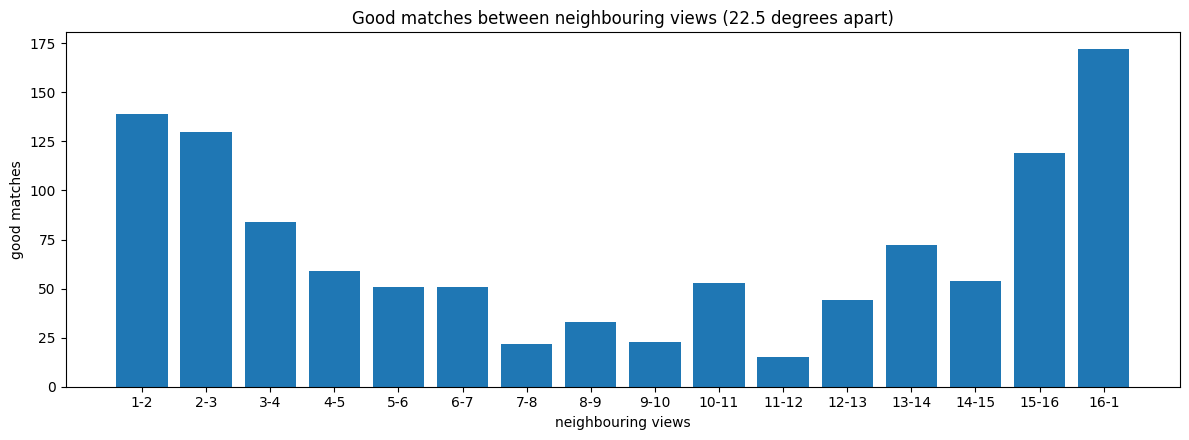

In [35]:
# Summary of experiment 1
print('{:>5} {:>13} {:>12} {:>11} {:>13} {:>12}'.format(
    'view', 'hat keypoints', 'left view', 'good left', 'right view', 'good right'))
for c, (n_left, n_right) in enumerate(neighbour_counts):
    print('{:>5} {:>13} {:>12} {:>11} {:>13} {:>12}'.format(
        c + 1, num_kp[c], (c - 1) % N_VIEWS + 1, n_left, (c + 1) % N_VIEWS + 1, n_right))

fig, ax = plt.subplots()
fig.set_size_inches(12, 4.5)
pairs = ['{}-{}'.format(c + 1, (c + 1) % N_VIEWS + 1) for c in range(N_VIEWS)]
ax.bar(pairs, [neighbour_counts[c][1] for c in range(N_VIEWS)])
ax.set_xlabel('neighbouring views')
ax.set_ylabel('good matches')
ax.set_title('Good matches between neighbouring views (22.5 degrees apart)')
plt.tight_layout()

# Matching All Pairs

All pairs are matches and grouped by how far apart the camera positions are from 22.5 up to 180 degrees. Each group the table gives the average, lowest, and highest number of good matches, the average matching score and the average descriptor distance.

In [ ]:
Cby_angle = {}
for a in range(N_VIEWS):
    for b in range(a + 1, N_VIEWS):
        good = lowe_match(a, b)
        score = len(good) / min(num_kp[a], num_kp[b])
        mean_d = np.mean([m.distance for m in good]) if good else np.nan
        by_angle.setdefault(view_angle(a, b), []).append((len(good), score, mean_d))

angles = sorted(by_angle)
avg_good = [np.mean([r[0] for r in by_angle[s]]) for s in angles]
avg_score = [np.mean([r[1] for r in by_angle[s]]) for s in angles]
print('{:>7} {:>6} {:>9} {:>6} {:>6} {:>16} {:>14}'.format(
    'change', 'pairs', 'avg good', 'min', 'max', 'matching score', 'mean distance'))
for s, g, sc in zip(angles, avg_good, avg_score):
    counts = [r[0] for r in by_angle[s]]
    print('{:>7.1f} {:>6} {:>9.1f} {:>6} {:>6} {:>15.1f}% {:>14.0f}'.format(
        s, len(counts), g, min(counts), max(counts), 100 * sc, np.nanmean([r[2] for r in by_angle[s]])))

fig, ax = plt.subplots(nrows=1, ncols=2)
fig.set_size_inches(15, 5)
ax[0].plot(angles, avg_good, 'o-')
ax[0].set_xlabel('viewpoint change (deg)')
ax[0].set_ylabel('average good matches per pair')
ax[0].set_title('Good matches vs viewpoint change')
ax[1].plot(angles, [100 * s for s in avg_score], 'o-')
ax[1].set_xlabel('viewpoint change (deg)')
ax[1].set_ylabel('matching score (%)')
ax[1].set_title('Matching score vs viewpoint change')
plt.tight_layout()

# Results

